# 02 – Data Preprocessing & Train/Test Split
**AlchemiX – Launch26 Phase 2**

## What this notebook does
1. Load raw CSVs from `datasets/raw/`
2. Clean each dataset (KNN impute, duplicate removal, schema validation)
3. **Perform Train/Test Split** (80/20, stratified for incident)
4. Save:
   - `datasets/cleaned/traffic_clean.csv` — full cleaned (for EDA reference)
   - `datasets/cleaned/traffic_train.csv` — training split ← used by Notebook 03
   - `datasets/cleaned/traffic_test.csv`  — test split    ← used by Notebook 03
   - *(same pattern for telemetry and incident)*

## Why split HERE (before feature engineering)?
Historical statistics (per-link mean load, mean trust score, attack rate) must
be computed **only from training rows** and then *mapped* to test rows.
If we compute these stats before splitting, test-set information leaks into training.
Splitting first eliminates this risk completely.

> **Rule**: split data is never re-joined or shuffled after this point.

In [2]:
import sys, pathlib
PROJECT_ROOT = pathlib.Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from ml.utils import (
    RANDOM_SEED,
    TRAFFIC_RAW_FILE, TELEMETRY_RAW_FILE, INCIDENT_RAW_FILE,
    TRAFFIC_CLEAN_FILE, TELEMETRY_CLEAN_FILE, INCIDENT_CLEAN_FILE,
    TRAFFIC_TRAIN_CLEAN, TRAFFIC_TEST_CLEAN,
    TELEMETRY_TRAIN_CLEAN, TELEMETRY_TEST_CLEAN,
    INCIDENT_TRAIN_CLEAN, INCIDENT_TEST_CLEAN,
)
from ml.preprocessing import clean_traffic, clean_telemetry, clean_incident

np.random.seed(RANDOM_SEED)
print('Imports OK ✓')

Imports OK ✓


---
## Step 1 — Load Raw Data

In [3]:
traffic_raw   = pd.read_csv(TRAFFIC_RAW_FILE)
telemetry_raw = pd.read_csv(TELEMETRY_RAW_FILE)
incident_raw  = pd.read_csv(INCIDENT_RAW_FILE)

print(f'Traffic   raw: {traffic_raw.shape}   columns: {list(traffic_raw.columns)}')
print(f'Telemetry raw: {telemetry_raw.shape}   columns: {list(telemetry_raw.columns)}')
print(f'Incident  raw: {incident_raw.shape}   columns: {list(incident_raw.columns)}')

Traffic   raw: (6000, 6)   columns: ['link_id', 'tick', 'load_units', 'load_ratio', 'status', 'observed_latency_ms']
Telemetry raw: (6000, 4)   columns: ['link_id', 'tick', 'self_reported_latency_ms', 'measured_latency_ms']
Incident  raw: (6000, 4)   columns: ['link_id', 'tick', 'traffic_share', 'jammed_flag']


---
## Step 2 — Missingness Overview (Before Cleaning)

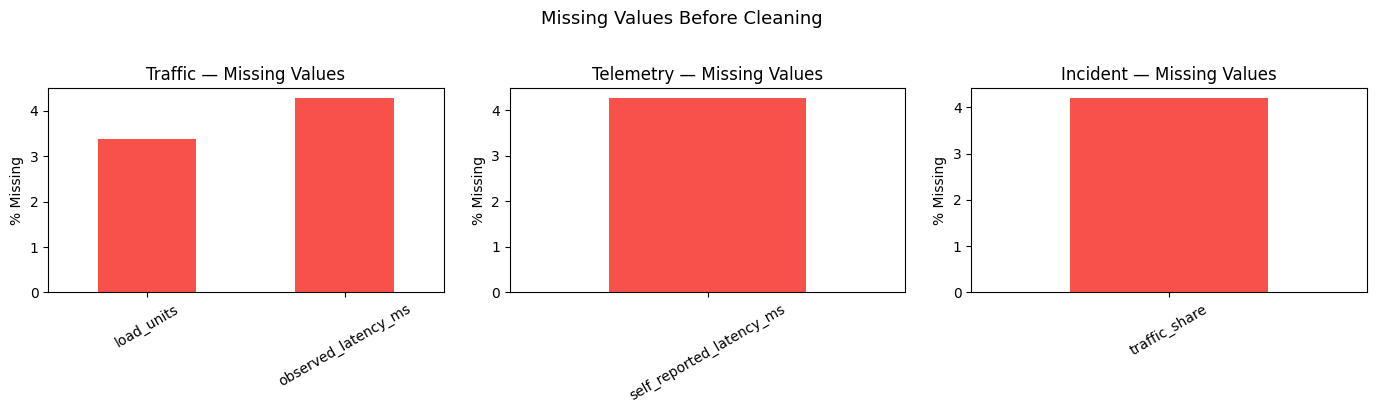

Traffic     total_missing=460  rows=6000
Telemetry   total_missing=256  rows=6000
Incident    total_missing=252  rows=6000


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (name, df) in zip(axes, [('Traffic', traffic_raw), ('Telemetry', telemetry_raw), ('Incident', incident_raw)]):
    missing = df.isnull().mean() * 100
    missing = missing[missing > 0]
    if missing.empty:
        ax.text(0.5, 0.5, 'No missing values', ha='center', va='center', transform=ax.transAxes)
    else:
        missing.plot.bar(ax=ax, color='#f85149')
        ax.set_ylabel('% Missing')
    ax.set_title(f'{name} — Missing Values')
    ax.tick_params(axis='x', rotation=30)
plt.suptitle('Missing Values Before Cleaning', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

for name, df in [('Traffic', traffic_raw), ('Telemetry', telemetry_raw), ('Incident', incident_raw)]:
    print(f'{name:10s}  total_missing={df.isnull().sum().sum()}  rows={len(df)}')

---
## Step 3 — Clean Each Dataset

In [5]:
traffic_clean   = clean_traffic(traffic_raw)
telemetry_clean = clean_telemetry(telemetry_raw)
incident_clean  = clean_incident(incident_raw)

print('\nCleaning summary:')
print(f'  Traffic:   {len(traffic_raw)} → {len(traffic_clean)} rows  (removed {len(traffic_raw)-len(traffic_clean)})')
print(f'  Telemetry: {len(telemetry_raw)} → {len(telemetry_clean)} rows  (removed {len(telemetry_raw)-len(telemetry_clean)})')
print(f'  Incident:  {len(incident_raw)} → {len(incident_clean)} rows  (removed {len(incident_raw)-len(incident_clean)})')

14:57:02  INFO      ml.preprocessing  [traffic] Schema OK – 6000 rows, 6 columns
14:57:02  INFO      ml.preprocessing  [traffic] Duplicates removed: 0 (rows remaining: 6000)
14:57:02  INFO      ml.preprocessing  [traffic] KNN imputation: 203 → 0 missing values in ['load_units', 'load_ratio']
14:57:02  INFO      ml.preprocessing  [traffic] Rows removed due to missing target 'observed_latency_ms': 257 (rows remaining: 5743)
14:57:02  INFO      ml.preprocessing  [traffic] No missing values remaining.
14:57:02  INFO      ml.preprocessing  [traffic] Cleaning complete – 5743 rows
14:57:02  INFO      ml.preprocessing  [telemetry] Schema OK – 6000 rows, 4 columns
14:57:02  INFO      ml.preprocessing  [telemetry] Duplicates removed: 0 (rows remaining: 6000)
14:57:02  INFO      ml.preprocessing  [telemetry] KNN imputation: 256 → 0 missing values in ['self_reported_latency_ms']
14:57:02  INFO      ml.preprocessing  [telemetry] Rows removed due to missing target 'measured_latency_ms': 0 (rows rema


Cleaning summary:
  Traffic:   6000 → 5743 rows  (removed 257)
  Telemetry: 6000 → 6000 rows  (removed 0)
  Incident:  6000 → 6000 rows  (removed 0)


In [6]:
print('Missing values after cleaning:')
for name, df in [('Traffic', traffic_clean), ('Telemetry', telemetry_clean), ('Incident', incident_clean)]:
    total = df.isnull().sum().sum()
    status = '✓' if total == 0 else '✗'
    print(f'  {status} {name:10s}  missing={total}')

Missing values after cleaning:
  ✓ Traffic     missing=0
  ✓ Telemetry   missing=0
  ✓ Incident    missing=0


---
## Step 4 — Train / Test Split

> **This is the critical anti-leakage gate.**
> All feature engineering in Notebook 03 will operate on each split independently.
> Historical per-link statistics will be computed from the **train split only** and mapped to test.

In [7]:
# ── Traffic (Regression target: observed_latency_ms) ─────────────────────────
# Simple random split — no stratification needed for regression.
traffic_train, traffic_test = train_test_split(
    traffic_clean,
    test_size=0.20,
    random_state=RANDOM_SEED,
    shuffle=True,
)
traffic_train = traffic_train.reset_index(drop=True)
traffic_test  = traffic_test.reset_index(drop=True)

print(f'Traffic:   train={len(traffic_train)}  test={len(traffic_test)}')
print(f'  Train target mean: {traffic_train["observed_latency_ms"].mean():.0f} ms')
print(f'  Test  target mean: {traffic_test["observed_latency_ms"].mean():.0f} ms')

Traffic:   train=4594  test=1149
  Train target mean: 194580 ms
  Test  target mean: 192961 ms


In [8]:
# ── Telemetry (Regression target: measured_latency_ms → becomes trust_score in NB03) ───
telemetry_train, telemetry_test = train_test_split(
    telemetry_clean,
    test_size=0.20,
    random_state=RANDOM_SEED,
    shuffle=True,
)
telemetry_train = telemetry_train.reset_index(drop=True)
telemetry_test  = telemetry_test.reset_index(drop=True)

print(f'Telemetry: train={len(telemetry_train)}  test={len(telemetry_test)}')

Telemetry: train=4800  test=1200


In [9]:
# ── Incident (Classification target: jammed_flag) ─────────────────────────────
# Stratified on jammed_flag to preserve class balance in both splits.
incident_clean['jammed_flag'] = incident_clean['jammed_flag'].astype(int)
incident_train, incident_test = train_test_split(
    incident_clean,
    test_size=0.20,
    random_state=RANDOM_SEED,
    stratify=incident_clean['jammed_flag'],
    shuffle=True,
)
incident_train = incident_train.reset_index(drop=True)
incident_test  = incident_test.reset_index(drop=True)

jam_train = incident_train['jammed_flag'].mean()
jam_test  = incident_test['jammed_flag'].mean()
print(f'Incident:  train={len(incident_train)}  test={len(incident_test)}')
print(f'  Train jam rate: {jam_train:.4f}  Test jam rate: {jam_test:.4f}  (should be equal ✓)')

Incident:  train=4800  test=1200
  Train jam rate: 0.0821  Test jam rate: 0.0825  (should be equal ✓)


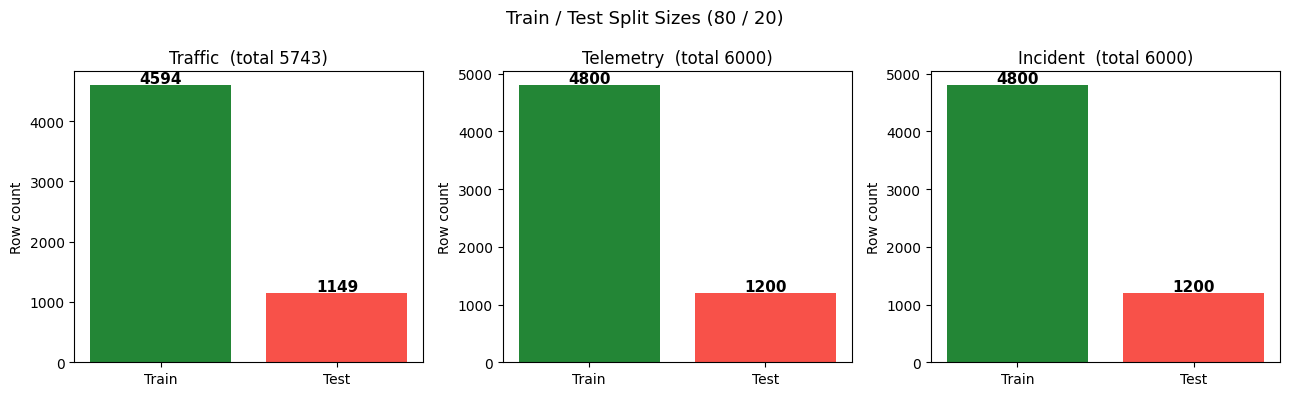

In [10]:
# Split size summary chart
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (name, tr, te) in zip(axes, [
    ('Traffic',   len(traffic_train),   len(traffic_test)),
    ('Telemetry', len(telemetry_train), len(telemetry_test)),
    ('Incident',  len(incident_train),  len(incident_test)),
]):
    ax.bar(['Train', 'Test'], [tr, te], color=['#238636', '#f85149'])
    ax.set_title(f'{name}  (total {tr+te})')
    ax.set_ylabel('Row count')
    for i, v in enumerate([tr, te]):
        ax.text(i, v + 30, str(v), ha='center', fontsize=11, fontweight='bold')
plt.suptitle('Train / Test Split Sizes (80 / 20)', fontsize=13)
plt.tight_layout()
plt.show()

---
## Step 5 — Save Cleaned & Split Files

In [11]:
# Full cleaned files (for EDA reference in Notebook 01 re-runs)
traffic_clean.to_csv(TRAFFIC_CLEAN_FILE,   index=False)
telemetry_clean.to_csv(TELEMETRY_CLEAN_FILE, index=False)
incident_clean.to_csv(INCIDENT_CLEAN_FILE,  index=False)

# Train splits
traffic_train.to_csv(TRAFFIC_TRAIN_CLEAN,   index=False)
telemetry_train.to_csv(TELEMETRY_TRAIN_CLEAN, index=False)
incident_train.to_csv(INCIDENT_TRAIN_CLEAN,  index=False)

# Test splits
traffic_test.to_csv(TRAFFIC_TEST_CLEAN,     index=False)
telemetry_test.to_csv(TELEMETRY_TEST_CLEAN,   index=False)
incident_test.to_csv(INCIDENT_TEST_CLEAN,    index=False)

print('Saved files:')
import pathlib
for f in [
    TRAFFIC_CLEAN_FILE, TRAFFIC_TRAIN_CLEAN, TRAFFIC_TEST_CLEAN,
    TELEMETRY_CLEAN_FILE, TELEMETRY_TRAIN_CLEAN, TELEMETRY_TEST_CLEAN,
    INCIDENT_CLEAN_FILE, INCIDENT_TRAIN_CLEAN, INCIDENT_TEST_CLEAN,
]:
    rows = len(pd.read_csv(f))
    print(f'  {pathlib.Path(f).name:<35}  {rows:5d} rows')

print('\n✓ Notebook 02 complete — proceed to Notebook 03 Feature Engineering.')

Saved files:
  traffic_clean.csv                     5743 rows
  traffic_train.csv                     4594 rows
  traffic_test.csv                      1149 rows
  telemetry_clean.csv                   6000 rows
  telemetry_train.csv                   4800 rows
  telemetry_test.csv                    1200 rows
  incident_clean.csv                    6000 rows
  incident_train.csv                    4800 rows
  incident_test.csv                     1200 rows

✓ Notebook 02 complete — proceed to Notebook 03 Feature Engineering.
